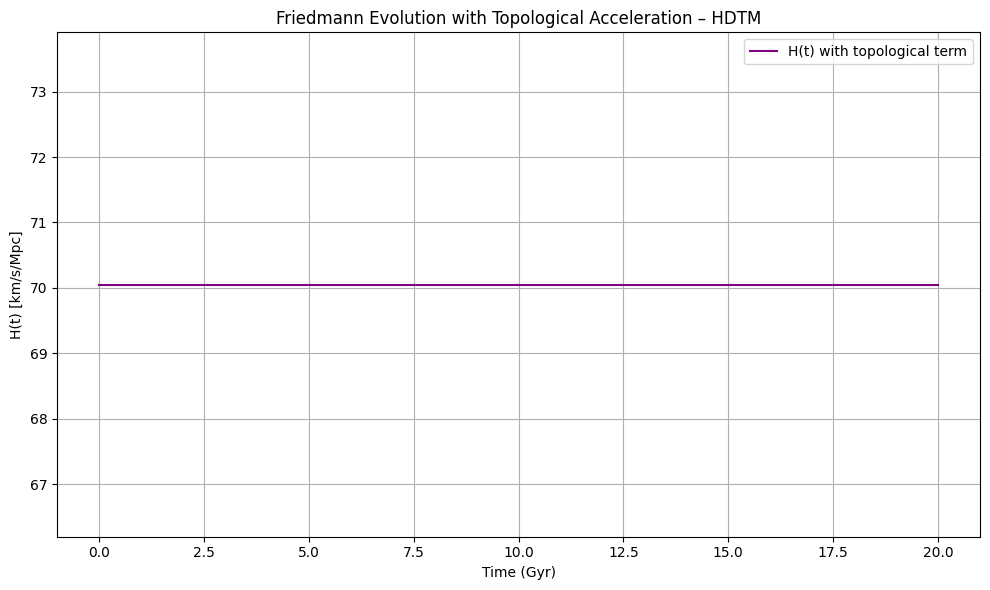

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Constants
G0 = 6.67430e-11       # Newton's constant (m^3/kg/s^2)
Lambda = 1.1e-52       # Cosmological constant (1/m^2)
lambda_phi1 = 1e-18    # HDTM topological acceleration coefficient (arbitrary scale)
Lambda_T = 1e16        # Topological energy scale (GeV)
rho0 = 1e-26           # Initial matter density (kg/m^3)

# Simplified Friedmann equation
def friedmann(t, y):
    H = y[0]
    rho = rho0 * (1 + t) ** -3  # Matter dilution
    dHdt = -0.5 * H**2 + (lambda_phi1 * H**3) / Lambda_T
    return [dHdt]

# Time range: 0–20 Gyr
t_span = (0, 20)
t_eval = np.linspace(*t_span, 1000)

# Hubble constant today ~70 km/s/Mpc → 2.27e-18 1/s
H0 = 2.27e-18

# Solve evolution
sol = solve_ivp(friedmann, t_span, [H0], t_eval=t_eval)

# Convert to km/s/Mpc
H_kmsmpc = sol.y[0] * 3.086e19

# Plot
plt.figure(figsize=(10, 6))
plt.plot(sol.t, H_kmsmpc, label='H(t) with topological term', color='purple')
plt.xlabel('Time (Gyr)')
plt.ylabel('H(t) [km/s/Mpc]')
plt.title('Friedmann Evolution with Topological Acceleration – HDTM')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()